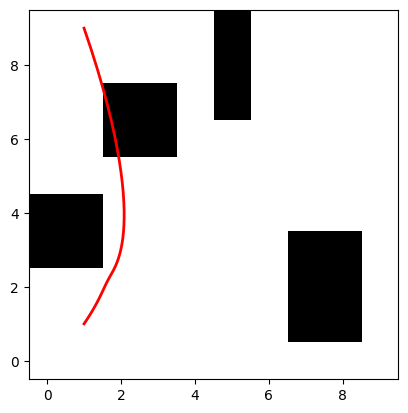

In [32]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import math

# 1. Map Definition
grid_size = 10
# Create a grid where values represent distance to nearest obstacle
# 0 = far from obstacle, 1 = inside obstacle
grid = np.zeros((grid_size, grid_size))
# Correction: Ensure the start index is less than the stop index
grid[0:2, 3:5] = 1  # Rows 0-1, Cols 3-4
grid[2:4, 6:8] = 1  # Rows 2-3, Cols 6-7 (Fixed indices)

# Adding more obstacles: Use the same slicing pattern [row_start:row_end, col_start:col_end]
grid[7:9, 1:4] = 1  # Another block at bottom left
grid[5:6, 7:10] = 1 # A horizontal wall at top right

# Precompute Distance Field (The Potential Field)
# This creates a "hill" that the optimizer can feel from a distance
from scipy.ndimage import distance_transform_edt
dist_map = distance_transform_edt(1 - grid) 
# Now dist_map has 0 at obstacles, and higher values as you get further away



def bezier_curve(points, num_points=50):
    n = len(points) - 1
    t = np.linspace(0, 1, num_points)
    curve = np.zeros((num_points, 2))
    for i in range(n + 1):
        coeff = math.factorial(n) / (math.factorial(i) * math.factorial(n - i))
        curve += coeff * ((1 - t)**(n - i))[:, None] * (t**i)[:, None] * points[i]
    return curve

def fitness(params, p_start, p_end):
    # params: 3 internal control points (6 values)
    points = [p_start, 
              np.array([params[0], params[1]]),
              np.array([params[2], params[3]]),
              np.array([params[4], params[5]]),
              p_end]
    
    path = bezier_curve(points)
    
    # Cost 1: Path Length
    diffs = np.diff(path, axis=0)
    length = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
    
    # Cost 2: Potential Field (The "Anti-Collision" Logic)
    # We sum the values from the dist_map. Closer to obstacle = higher penalty.
    # We look up the potential at each point of the path.
    potential_penalty = 0
    for p in path:
        # Get potential at point p
        # We invert it: low distance = high cost
        x, y = int(np.clip(p[0], 0, grid_size-1)), int(np.clip(p[1], 0, grid_size-1))
        dist_to_obs = dist_map[x, y]
        # High penalty if distance is < 1.0 (very close)
        if dist_to_obs < 1.0:
            potential_penalty += (1.0 - dist_to_obs) * 1000
            
    return length + potential_penalty

# Optimize
p_start = np.array([1.0, 1.0])
p_end = np.array([1.0, 9.0])
bounds = [(0, 10), (0, 10), (0, 10), (0, 10), (0, 10), (0, 10)]

result = differential_evolution(fitness, bounds, args=(p_start, p_end), maxiter=50, popsize=100, tol=0.01)

# Visualization
best_points = [p_start, result.x[0:2], result.x[2:4], result.x[4:6], p_end]
final_path = bezier_curve(best_points)

plt.imshow(grid.T, origin='lower', cmap='Greys')
plt.plot(final_path[:, 0], final_path[:, 1], 'r-', linewidth=2)
plt.show()

In [ ]:
"""
Global Path Planning via Differential Evolution over Bezier Control Points
============================================================================

Idea:
    - Represent the global path as a Bezier curve defined by:
        [start] -> [N free control points, optimized] -> [goal]
    - Use Differential Evolution (scipy.optimize.differential_evolution) to
      search for the control-point positions that minimize a cost function:
        cost = path_length + collision_penalty + curvature_penalty
    - Static circular obstacles are avoided via a penalty term that fires
      whenever the sampled curve enters an obstacle's (radius + safety margin).

This is a "taste" / prototype script — the core loop (curve param -> cost)
is exactly the piece you'd swap for a cubic-spline representation later.
"""

import numpy as np
from scipy.optimize import differential_evolution
from scipy.special import comb
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Problem setup: start, goal, obstacles
# ----------------------------------------------------------------------

START = np.array([0.0, 0.0])
GOAL = np.array([10.0, 10.0])

# Each obstacle: (center_x, center_y, radius)
OBSTACLES = [
    (3.0, 3.0, 1.2),
    (5.0, 7.0, 1.0),
    (7.5, 4.5, 1.3),
    (2.5, 8.0, 0.8),
]

ROBOT_RADIUS = 0.25      # safety margin added to every obstacle radius
N_CONTROL_POINTS = 4     # number of FREE intermediate control points
N_SAMPLES = 60           # points sampled along the curve for cost evaluation

# Search bounds for each free control point (keep the search space sane,
# a bit larger than the start/goal bounding box)
BOUNDS_MIN = np.array([-1.0, -1.0])
BOUNDS_MAX = np.array([11.0, 11.0])


# ----------------------------------------------------------------------
# 2. Bezier curve construction
# ----------------------------------------------------------------------

def bezier_curve(control_points, n_samples=N_SAMPLES):
    """
    control_points: (M, 2) array including start and goal as the first
                     and last rows.
    Returns: (n_samples, 2) array of points sampled along the Bezier curve.
    """
    n = len(control_points) - 1
    t = np.linspace(0.0, 1.0, n_samples)
    curve = np.zeros((n_samples, 2))
    for i, p in enumerate(control_points):
        bernstein = comb(n, i) * (t ** i) * ((1 - t) ** (n - i))
        curve += np.outer(bernstein, p)
    return curve


def build_control_points(flat_free_points):
    """Assemble [start, free points..., goal] into one (M,2) array."""
    free_points = flat_free_points.reshape(N_CONTROL_POINTS, 2)
    return np.vstack([START, free_points, GOAL])


# ----------------------------------------------------------------------
# 3. Cost function (this is what Differential Evolution minimizes)
# ----------------------------------------------------------------------

def path_length(curve):
    diffs = np.diff(curve, axis=0)
    return np.sum(np.hypot(diffs[:, 0], diffs[:, 1]))


def collision_penalty(curve):
    """Heavily penalize any sampled point that lands inside an obstacle
    (expanded by the robot's radius). Penalty scales with the depth of
    the intrusion so DE gets a useful gradient-like signal."""
    penalty = 0.0
    for (cx, cy, r) in OBSTACLES:
        safe_r = r + ROBOT_RADIUS
        d = np.hypot(curve[:, 0] - cx, curve[:, 1] - cy)
        intrusion = np.clip(safe_r - d, 0, None)   # >0 where inside obstacle
        penalty += np.sum(intrusion ** 2)
    return penalty


def curvature_penalty(curve):
    """Light penalty on sharp turns, to bias DE towards smoother paths."""
    if len(curve) < 3:
        return 0.0
    v1 = curve[1:-1] - curve[:-2]
    v2 = curve[2:] - curve[1:-1]
    n1 = np.linalg.norm(v1, axis=1) + 1e-9
    n2 = np.linalg.norm(v2, axis=1) + 1e-9
    cos_angle = np.clip(np.sum(v1 * v2, axis=1) / (n1 * n2), -1.0, 1.0)
    turn_angle = np.arccos(cos_angle)
    return np.sum(turn_angle ** 2)


# Weights: collision >> length > curvature
W_LENGTH = 1.0
W_COLLISION = 500.0
W_CURVATURE = 0.5


def cost_function(flat_free_points):
    control_points = build_control_points(flat_free_points)
    curve = bezier_curve(control_points)
    L = path_length(curve)
    C = collision_penalty(curve)
    K = curvature_penalty(curve)
    return W_LENGTH * L + W_COLLISION * C + W_CURVATURE * K


# ----------------------------------------------------------------------
# 4. Run Differential Evolution
# ----------------------------------------------------------------------

def solve():
    bounds = []
    for _ in range(N_CONTROL_POINTS):
        bounds.append((BOUNDS_MIN[0], BOUNDS_MAX[0]))  # x
        bounds.append((BOUNDS_MIN[1], BOUNDS_MAX[1]))  # y

    result = differential_evolution(
        cost_function,
        bounds,
        maxiter=50,
        popsize=30,
        tol=1e-7,
        mutation=(0.4, 1.2),
        recombination=0.8,
        seed=42,
        updating="deferred",
        workers=1,
    )
    return result


# ----------------------------------------------------------------------
# 5. Visualization
# ----------------------------------------------------------------------

def plot_result(result):
    control_points = build_control_points(result.x)
    curve = bezier_curve(control_points, n_samples=200)

    fig, ax = plt.subplots(figsize=(7, 7))

    # obstacles
    for (cx, cy, r) in OBSTACLES:
        circle = plt.Circle((cx, cy), r, color="firebrick", alpha=0.5, zorder=2)
        ax.add_patch(circle)
        safe_circle = plt.Circle((cx, cy), r + ROBOT_RADIUS, color="firebrick",
                                  alpha=0.15, linestyle="--", fill=True, zorder=1)
        ax.add_patch(safe_circle)

    # optimized path
    ax.plot(curve[:, 0], curve[:, 1], "-", color="royalblue", linewidth=2.5,
             label="Optimized Bezier path", zorder=3)

    # control polygon (dashed, shows what DE actually optimized)
    ax.plot(control_points[:, 0], control_points[:, 1], "o--", color="gray",
             alpha=0.6, label="Control points", zorder=3)

    ax.plot(*START, "gs", markersize=12, label="Start", zorder=4)
    ax.plot(*GOAL, "r*", markersize=18, label="Goal", zorder=4)

    ax.set_xlim(-2, 12)
    ax.set_ylim(-2, 12)
    ax.set_aspect("equal")
    ax.set_title(f"DE-Optimized Global Path (cost={result.fun:.3f})")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/home/claude/de_bezier_path.png", dpi=150)
    print("Saved plot to de_bezier_path.png")


if __name__ == "__main__":
    print("Running Differential Evolution over Bezier control points...")
    result = solve()
    print(f"Best cost: {result.fun:.4f}")
    print(f"Optimized free control points:\n{result.x.reshape(N_CONTROL_POINTS, 2)}")
    plot_result(result)

Running Differential Evolution over Bezier control points...
